## Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Loading the Dataset

In [2]:
df = pd.read_csv("creditcard.csv")

df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
df.shape

(284807, 31)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [5]:
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(1081)

## Understanding the target variable

In [10]:
df['Class'].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

In [11]:
df['Class'].value_counts(normalize=True) * 100

Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64

In [12]:
fraud_summary = df.groupby('Class')['Amount'].agg(
    ['count', 'mean', 'median', 'min', 'max', 'sum']
)

fraud_summary

,count,mean,median,min,max,sum
Class,,,,,,
0,284315,88.291022,22.00,0.0,25691.16,25102462.04
1,492,122.211321,9.25,0.0,2125.87,60127.97


## Investigating duplicates

In [13]:
# Number of duplicate rows by Class
df[df.duplicated(keep=False)]['Class'].value_counts()

Class
0    1822
1      32
Name: count, dtype: int64

In [14]:
# Comparing duplicate and non-duplicate transactions
duplicate_flag = df.duplicated(keep=False)

df.groupby(duplicate_flag)['Class'].value_counts()

       Class
False  0        282493
       1           460
True   0          1822
       1            32
Name: count, dtype: int64

In [15]:
# Duplicate rows by class
duplicate_summary = (
    df[df.duplicated(keep=False)]
    .groupby('Class')
    .size()
)

duplicate_summary

Class
0    1822
1      32
dtype: int64

## Analyzing transaction amounts

In [16]:
amount_summary = df.groupby('Class')['Amount'].describe()

amount_summary

,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
0,284315.0,88.291022,250.105092,0.0,5.65,22.00,77.05,25691.16
1,492.0,122.211321,256.683288,0.0,1.00,9.25,105.89,2125.87


In [17]:
df['Amount_Band'] = pd.cut(
    df['Amount'],
    bins=[-1, 10, 50, 100, 500, 1000, float('inf')],
    labels=['0-10', '10-50', '50-100', '100-500', '500-1000', '1000+']
)

amount_band_analysis = pd.crosstab(
    df['Amount_Band'],
    df['Class'],
    normalize='index'
) * 100

amount_band_analysis

Class,0,1
Amount_Band,,
0-10,99.751656,0.248344
10-50,99.937212,0.062788
50-100,99.849681,0.150319
100-500,99.799434,0.200566
500-1000,99.580780,0.419220
1000+,99.693878,0.306122


In [18]:
amount_band_counts = pd.crosstab(
    df['Amount_Band'],
    df['Class']
)

amount_band_counts

Class,0,1
Amount_Band,,
0-10,100015,249
10-50,90724,57
50-100,37198,56
100-500,47271,95
500-1000,6176,26
1000+,2931,9


## Analyzing fraud over time

In [19]:
df['Hour'] = (df['Time'] // 3600).astype(int)

hourly_fraud = df.groupby('Hour')['Class'].agg(
    transactions='count',
    frauds='sum'
)

hourly_fraud['fraud_rate'] = (
    hourly_fraud['frauds'] / hourly_fraud['transactions'] * 100
)

hourly_fraud

,transactions,frauds,fraud_rate
Hour,,,
0,3963,2,0.050467
1,2217,2,0.090212
2,1576,21,1.332487
3,1821,13,0.713893
4,1082,6,0.554529
5,1681,11,0.654372
6,1831,3,0.163845
7,3368,23,0.682898
8,5179,5,0.096544


In [20]:
hourly_fraud.sort_values(
    'fraud_rate',
    ascending=False
).head(10)

,transactions,frauds,fraud_rate
Hour,,,
26,1752,36,2.054795
28,1127,17,1.508429
2,1576,21,1.332487
3,1821,13,0.713893
7,3368,23,0.682898
5,1681,11,0.654372
4,1082,6,0.554529
11,8517,43,0.504873
25,2003,8,0.399401


In [21]:
hourly_fraud['frauds'].sum()

np.int64(492)

## Conversion of Time into Day + Hour

In [22]:
df['Day'] = (df['Time'] // 86400).astype(int)

df['Hour_of_Day'] = ((df['Time'] % 86400) // 3600).astype(int)

df[['Time', 'Day', 'Hour_of_Day']].head(10)

,Time,Day,Hour_of_Day
0,0.0,0,0
1,0.0,0,0
2,1.0,0,0
3,1.0,0,0
4,2.0,0,0
5,2.0,0,0
6,4.0,0,0
7,7.0,0,0
8,7.0,0,0
9,9.0,0,0


In [23]:
hour_of_day_analysis = df.groupby('Hour_of_Day')['Class'].agg(
    transactions='count',
    frauds='sum'
)

hour_of_day_analysis['fraud_rate'] = (
    hour_of_day_analysis['frauds']
    / hour_of_day_analysis['transactions']
    * 100
)

hour_of_day_analysis

,transactions,frauds,fraud_rate
Hour_of_Day,,,
0,7695,6,0.077973
1,4220,10,0.236967
2,3328,57,1.712740
3,3492,17,0.486827
4,2209,23,1.041195
5,2990,11,0.367893
6,4101,9,0.219459
7,7243,23,0.317548
8,10276,9,0.087583


In [24]:
hour_of_day_analysis.sort_values(
    'fraud_rate',
    ascending=False
).head(10)

,transactions,frauds,fraud_rate
Hour_of_Day,,,
2,3328,57,1.712740
4,2209,23,1.041195
3,3492,17,0.486827
5,2990,11,0.367893
7,7243,23,0.317548
11,16856,53,0.314428
1,4220,10,0.236967
6,4101,9,0.219459
18,17039,33,0.193673


## Analyzing the PCA features

In [25]:
feature_means = df.groupby('Class')[
    [f'V{i}' for i in range(1, 29)]
].mean().T

feature_means.columns = ['Legitimate', 'Fraud']

feature_means

,Legitimate,Fraud
V1,0.008258,-4.771948
V2,-0.006271,3.623778
V3,0.012171,-7.033281
V4,-0.007860,4.542029
V5,0.005453,-3.151225
V6,0.002419,-1.397737
V7,0.009637,-5.568731
V8,-0.000987,0.570636
V9,0.004467,-2.581123
V10,0.009824,-5.676883


In [26]:
feature_means['Absolute_Difference'] = abs(
    feature_means['Fraud'] - feature_means['Legitimate']
)

feature_means.sort_values(
    'Absolute_Difference',
    ascending=False
)

,Legitimate,Fraud,Absolute_Difference
V3,0.012171,-7.033281,7.045452
V14,0.012064,-6.971723,6.983787
V17,0.011535,-6.665836,6.677371
V12,0.010832,-6.259393,6.270225
V10,0.009824,-5.676883,5.686707
V7,0.009637,-5.568731,5.578368
V1,0.008258,-4.771948,4.780206
V4,-0.007860,4.542029,4.549889
V16,0.007164,-4.139946,4.147110
V11,-0.006576,3.800173,3.806749


## Correlation with fraud

In [27]:
correlation_with_class = (
    df.drop(columns=['Amount_Band'])
      .corr()['Class']
      .drop('Class')
      .sort_values()
)

correlation_with_class

V17           -0.326481
V14           -0.302544
V12           -0.260593
V10           -0.216883
V16           -0.196539
V3            -0.192961
V7            -0.187257
V18           -0.111485
V1            -0.101347
V9            -0.097733
V5            -0.094974
V6            -0.043643
Hour_of_Day   -0.017109
Hour          -0.012326
Time          -0.012323
V24           -0.007221
Day           -0.005223
V13           -0.004570
V15           -0.004223
V23           -0.002685
V22            0.000805
V25            0.003308
V26            0.004455
Amount         0.005632
V28            0.009536
V27            0.017580
V8             0.019875
V20            0.020090
V19            0.034783
V21            0.040413
V2             0.091289
V4             0.133447
V11            0.154876
Name: Class, dtype: float64

In [28]:
correlation_with_class.abs().sort_values(
    ascending=False
).head(15)

V17    0.326481
V14    0.302544
V12    0.260593
V10    0.216883
V16    0.196539
V3     0.192961
V7     0.187257
V11    0.154876
V4     0.133447
V18    0.111485
V1     0.101347
V9     0.097733
V5     0.094974
V2     0.091289
V6     0.043643
Name: Class, dtype: float64

## Visualizing the strongest PCA features

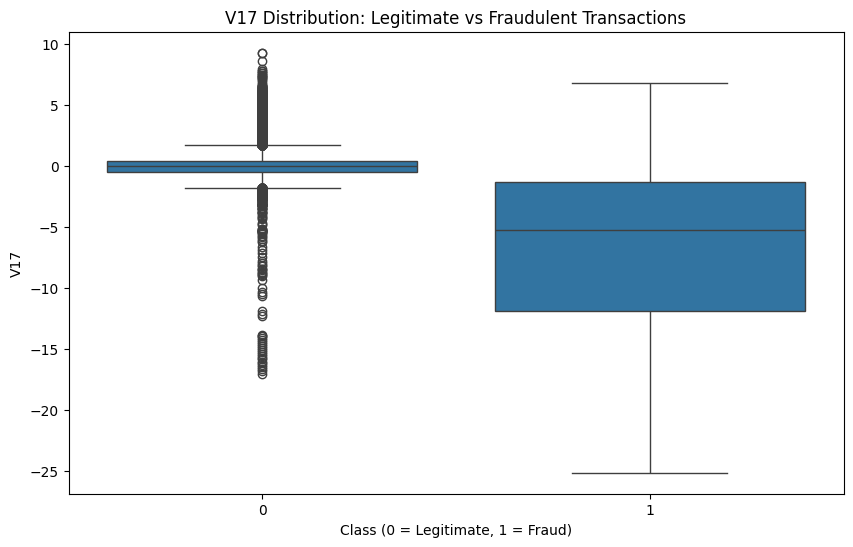

In [29]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x='Class',
    y='V17'
)

plt.title('V17 Distribution: Legitimate vs Fraudulent Transactions')
plt.xlabel('Class (0 = Legitimate, 1 = Fraud)')
plt.ylabel('V17')
plt.show()

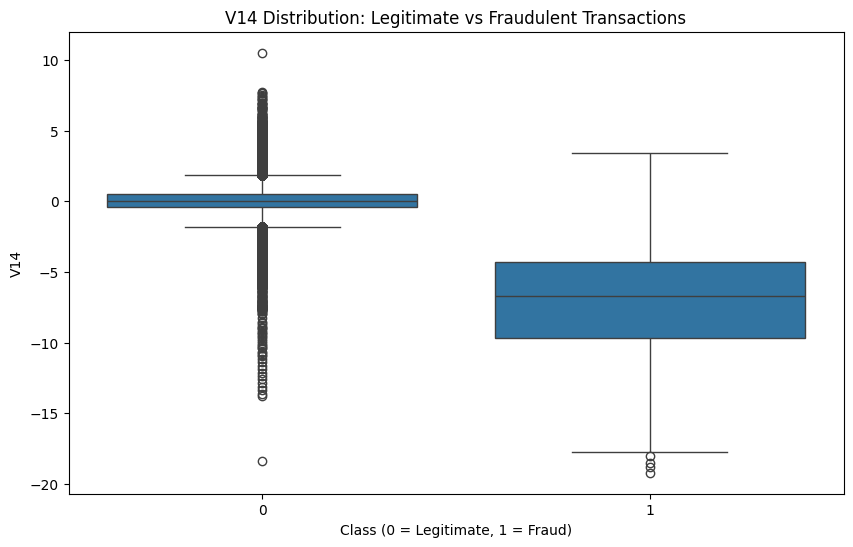

In [30]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x='Class',
    y='V14'
)

plt.title('V14 Distribution: Legitimate vs Fraudulent Transactions')
plt.xlabel('Class (0 = Legitimate, 1 = Fraud)')
plt.ylabel('V14')
plt.show()

## Creating a top-feature comparison

In [31]:
top_features = (
    correlation_with_class
    .abs()
    .sort_values(ascending=False)
    .head(10)
)

top_features

V17    0.326481
V14    0.302544
V12    0.260593
V10    0.216883
V16    0.196539
V3     0.192961
V7     0.187257
V11    0.154876
V4     0.133447
V18    0.111485
Name: Class, dtype: float64

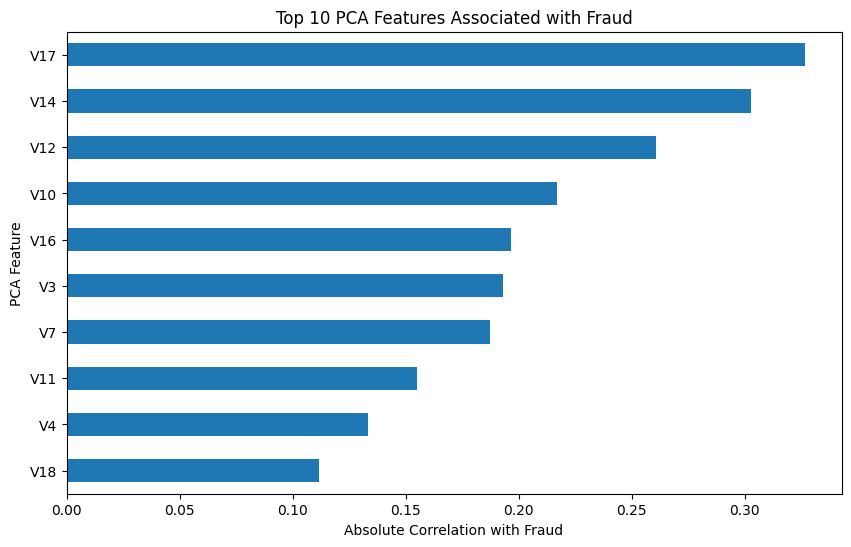

In [32]:
plt.figure(figsize=(10, 6))

top_features.sort_values().plot(kind='barh')

plt.title('Top 10 PCA Features Associated with Fraud')
plt.xlabel('Absolute Correlation with Fraud')
plt.ylabel('PCA Feature')
plt.show()

## Relationship between Amount and fraud

In [33]:
amount_percentiles = df.groupby('Class')['Amount'].quantile(
    [0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
).unstack()

amount_percentiles

,0.25,0.50,0.75,0.90,0.95,0.99
Class,,,,,,
0,5.65,22.00,77.05,202.724,364.409,1016.9664
1,1.00,9.25,105.89,346.746,640.905,1357.4279


In [34]:
amount_99th = df['Amount'].quantile(0.99)

print("99th percentile transaction amount:", amount_99th)

df.groupby('Class')['Amount'].apply(
    lambda x: (x >= amount_99th).sum()
)

99th percentile transaction amount: 1017.9700000000012


Class
0    2840
1       9
Name: Amount, dtype: int64

## Transaction amount distribution

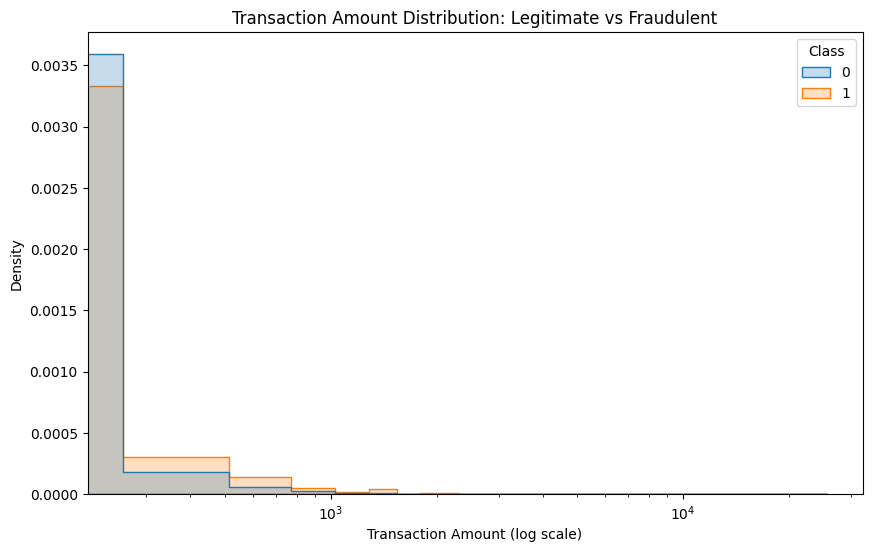

In [36]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x='Amount',
    hue='Class',
    bins=100,
    element='step',
    stat='density',
    common_norm=False
)

plt.xscale('log')
plt.title('Transaction Amount Distribution: Legitimate vs Fraudulent')
plt.xlabel('Transaction Amount (log scale)')
plt.ylabel('Density')
plt.show()

## Fraud rate by hour

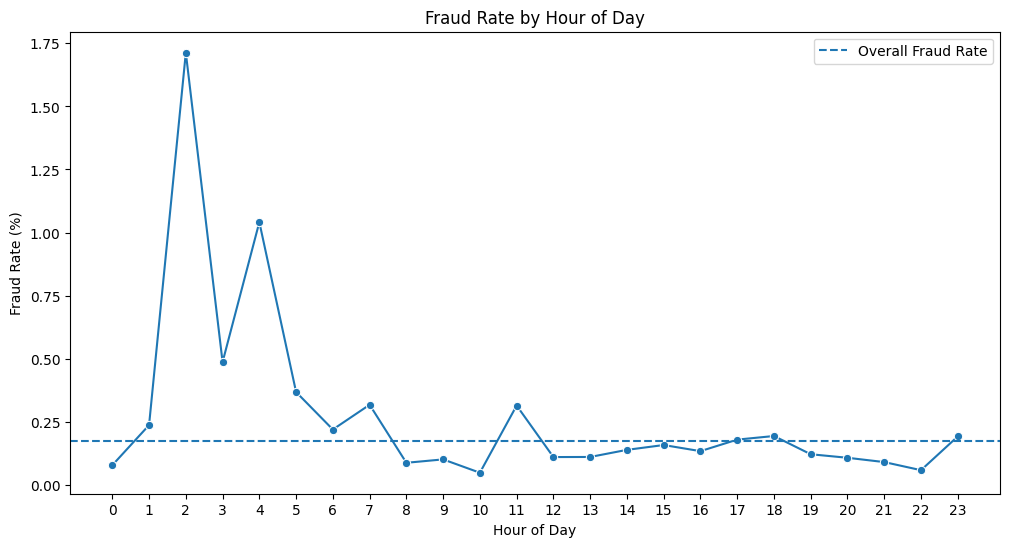

In [38]:
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=hour_of_day_analysis,
    x=hour_of_day_analysis.index,
    y='fraud_rate',
    marker='o'
)

plt.axhline(
    y=(df['Class'].mean() * 100),
    linestyle='--',
    label='Overall Fraud Rate'
)

plt.title('Fraud Rate by Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Fraud Rate (%)')
plt.xticks(range(24))
plt.legend()
plt.show()

## Fraud count by hour

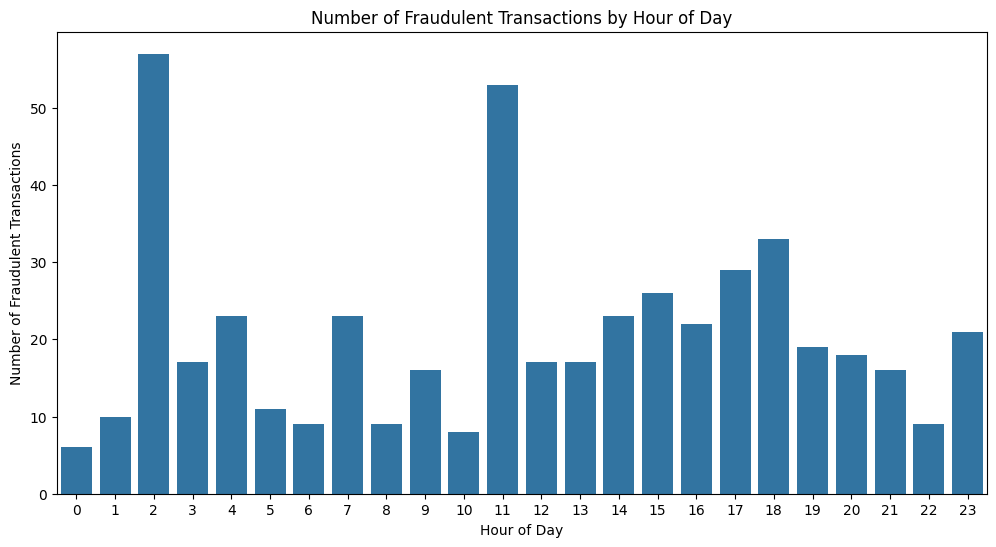

In [37]:
plt.figure(figsize=(12, 6))

sns.barplot(
    x=hour_of_day_analysis.index,
    y=hour_of_day_analysis['frauds']
)

plt.title('Number of Fraudulent Transactions by Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Fraudulent Transactions')
plt.xticks(range(24))
plt.show()